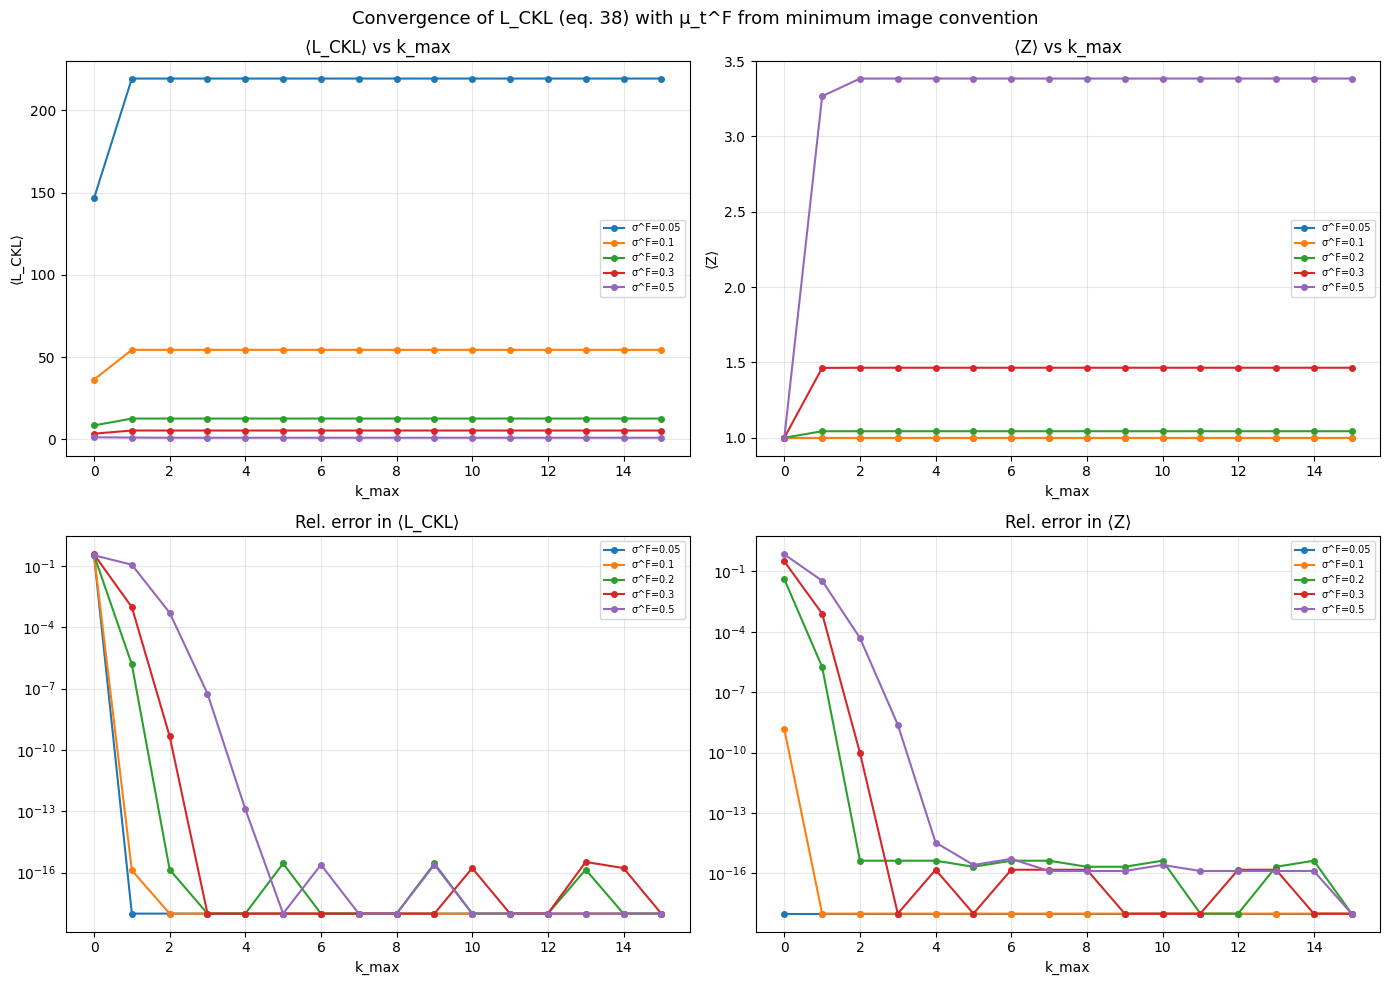


     s^F |  k_max for <1e-6 |  k_max for <1e-10 |    ⟨L_CKL⟩(k=15)
--------------------------------------------------------------------
   0.050 |                1 |                 1 |   2.18878146e+02
   0.100 |                1 |                 1 |   5.28019871e+01
   0.200 |                2 |                 2 |   1.25205797e+01
   0.300 |                2 |                 3 |   4.96996360e+00
   0.500 |                3 |                 4 |   7.94825649e-01


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def wrap(x):
    """Wrapping operation w(x) = x - floor(x), maps to [0, 1)."""
    return x - np.floor(x)


def mu_t_F(mu_0_F, x1, t):
    """
    Mean of conditional probability path (eq. from the paper):
    mu_t^F = mu_0^F + t * w(x1 - mu_0^F - 0.5) - 0.5)
    
    Uses minimum image convention for periodicity.
    """
    # Minimum image displacement: wrap(x1 - mu_0^F - 0.5) - 0.5
    displacement = wrap(x1 - mu_0_F - 0.5) - 0.5
    return mu_0_F + t * displacement


def compute_loss_and_Z(x, mu_t, sigma_F, v_theta, t, k_max):
    """
    Compute L_CKL (eq. 38) and Z (eq. 39) with the wrapped Gaussian on [0,1)^3.
    
    p_t^F(x) = N_w(x | mu_t^F, (\sigma^F)^2 I) ∝ sum_k exp(-||x - mu_t^F + k||^2 / (2*(\sigma^F)^2))
    
    Note: eq. 36 has +k in the numerator, so the lattice shift is x - mu_t + k.
    """
    variance = sigma_F ** 2

    ks = np.arange(-k_max, k_max + 1)
    kx, ky, kz = np.meshgrid(ks, ks, ks, indexing='ij')
    k_vecs = np.stack([kx.ravel(), ky.ravel(), kz.ravel()], axis=-1)

    # Per eq. 36: ||x - mu_t^F + k||^2
    diff = x - mu_t + k_vecs  # (N, 3)
    sq_norms = np.sum(diff ** 2, axis=-1)

    # Gaussian weights (unnormalized, prefactor cancels in loss)
    log_weights = -sq_norms / (2 * variance)
    log_weights -= np.max(log_weights)  # numerical stability
    weights = np.exp(log_weights)

    Z = np.sum(weights)

    # Model prediction term: ||x - t * v_theta||^2
    # But on torus, we should wrap: w(x - t * v_theta)
    pred_diff = x - t * v_theta
    sq_norm_pred = np.sum(pred_diff ** 2)

    # Bracket: ||x - mu_t + k||^2 - ||x - t*v_theta||^2
    bracket = sq_norms - sq_norm_pred

    # Loss = (1/Z) * sum_k weights_k * (-1/(2*variance)) * bracket_k
    loss = (1.0 / Z) * np.sum((weights / np.sum(weights) * Z) * (-1.0 / (2 * variance)) * bracket)
    # Simplify: weights already unnormalized, just use normalized
    norm_weights = weights / Z
    loss = np.sum(norm_weights * (-1.0 / (2 * variance)) * bracket)

    return loss, Z


# --- Test convergence ---
sigma_F_values = [0.05, 0.1, 0.2, 0.3, 0.5]
k_max_range = np.arange(0, 16)

N_samples = 300
rng = np.random.RandomState(42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for sigma_F in sigma_F_values:
    avg_losses = np.zeros(len(k_max_range))
    avg_Z = np.zeros(len(k_max_range))

    for _ in range(N_samples):
        # Sample prior: mu_0^F ~ U(0,1)^3
        mu_0_F = rng.rand(3)
        x1 = rng.rand(3)
        t = rng.uniform(0.01, 0.99)

        # Compute mu_t^F using minimum image convention
        mu_t = mu_t_F(mu_0_F, x1, t)

        # Sample x from the wrapped Gaussian (approximate: just use mu_t + noise, wrapped)
        x = wrap(mu_t + rng.randn(3) * sigma_F)

        # Imperfect velocity model
        ideal_v = (x1 - mu_0_F)  # rough target
        v_theta = ideal_v + rng.randn(3) * 0.05

        for j, k_max in enumerate(k_max_range):
            loss, Z = compute_loss_and_Z(x, mu_t, sigma_F, v_theta, t, k_max)
            avg_losses[j] += loss
            avg_Z[j] += Z

    avg_losses /= N_samples
    avg_Z /= N_samples

    axes[0, 0].plot(k_max_range, avg_losses, 'o-', label=f'σ^F={sigma_F}', markersize=4)
    axes[0, 1].plot(k_max_range, avg_Z, 'o-', label=f'σ^F={sigma_F}', markersize=4)

    L_final = avg_losses[-1]
    Z_final = avg_Z[-1]

    if L_final != 0:
        rel_loss = np.clip(np.abs(avg_losses - L_final) / max(np.abs(L_final), 1e-300), 1e-18, None)
        axes[1, 0].plot(k_max_range, rel_loss, 'o-', label=f'σ^F={sigma_F}', markersize=4)

    if Z_final != 0:
        rel_Z = np.clip(np.abs(avg_Z - Z_final) / max(np.abs(Z_final), 1e-300), 1e-18, None)
        axes[1, 1].plot(k_max_range, rel_Z, 'o-', label=f'σ^F={sigma_F}', markersize=4)

axes[0, 0].set_title("⟨L_CKL⟩ vs k_max"); axes[0, 0].set_ylabel("⟨L_CKL⟩")
axes[0, 1].set_title("⟨Z⟩ vs k_max"); axes[0, 1].set_ylabel("⟨Z⟩")
axes[1, 0].set_title("Rel. error in ⟨L_CKL⟩"); axes[1, 0].set_yscale('log')
axes[1, 1].set_title("Rel. error in ⟨Z⟩"); axes[1, 1].set_yscale('log')

for ax in axes.flat:
    ax.set_xlabel("k_max")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Convergence of L_CKL (eq. 38) with μ_t^F from minimum image convention", fontsize=13)
plt.tight_layout()
plt.savefig("convergence_LCKL_full.png", dpi=150)
plt.show()

# --- Summary ---
print(f"\n{'s^F':>8} | {'k_max for <1e-6':>16} | {'k_max for <1e-10':>17} | {'⟨L_CKL⟩(k=15)':>16}")
print("-" * 68)
for sigma_F in sigma_F_values:
    avg_losses = np.zeros(len(k_max_range))
    for _ in range(N_samples):
        mu_0_F = rng.rand(3)
        x1 = rng.rand(3)
        t = rng.uniform(0.01, 0.99)
        mu_t = mu_t_F(mu_0_F, x1, t)
        x = wrap(mu_t + rng.randn(3) * sigma_F)
        v_theta = (x1 - mu_0_F) + rng.randn(3) * 0.05
        for j, k_max in enumerate(k_max_range):
            loss, _ = compute_loss_and_Z(x, mu_t, sigma_F, v_theta, t, k_max)
            avg_losses[j] += loss
    avg_losses /= N_samples
    L_final = avg_losses[-1]

    k6 = k10 = "N/A"
    for i, k in enumerate(k_max_range):
        rel = abs(avg_losses[i] - L_final) / max(abs(L_final), 1e-300)
        if rel < 1e-6 and k6 == "N/A": k6 = str(k)
        if rel < 1e-10 and k10 == "N/A": k10 = str(k)

    print(f"{sigma_F:>8.3f} | {k6:>16} | {k10:>17} | {L_final:>16.8e}")

/tmp/ipykernel_1228/1453616147.py:158: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  avg_jsd[j] += jsd


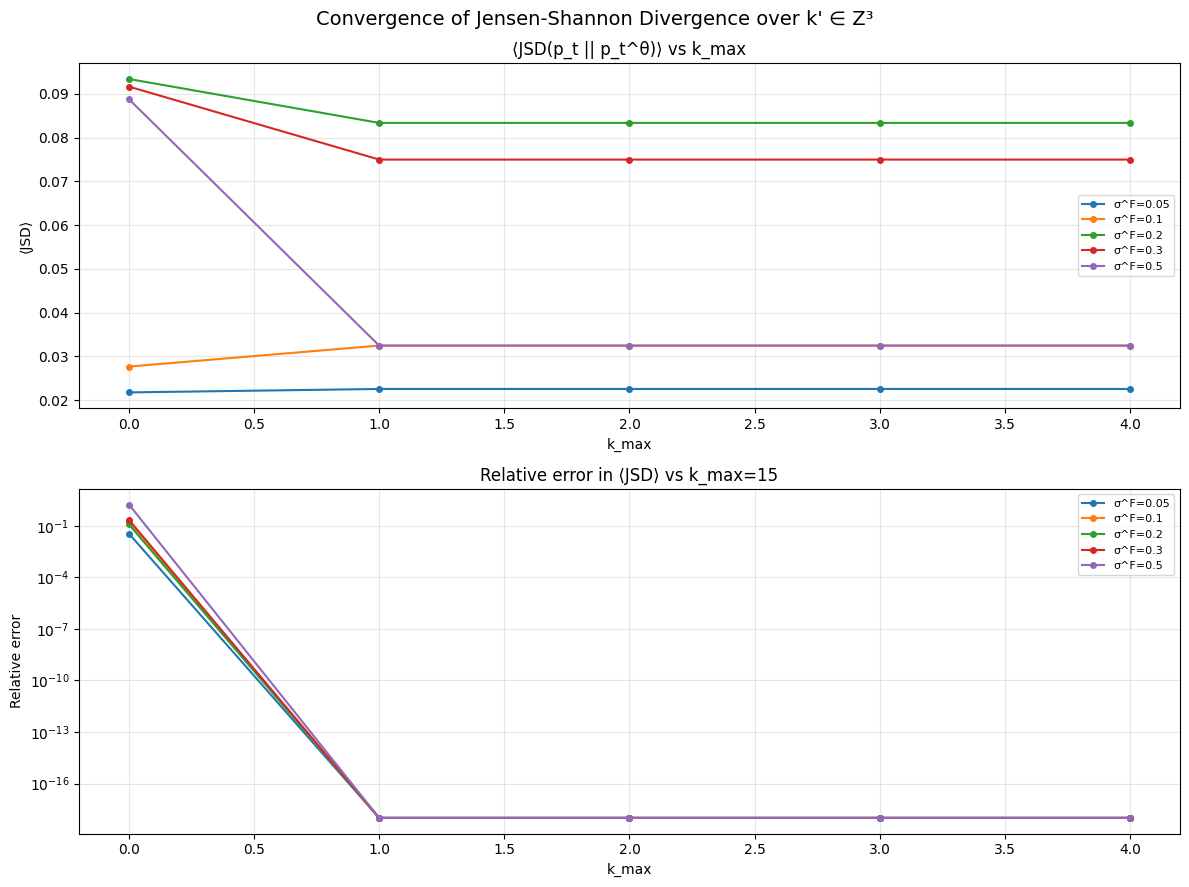


     σ^F |  k_max for <1e-6 |  k_max for <1e-10 |      ⟨JSD⟩(k=15)
--------------------------------------------------------------------
   0.050 |                1 |                 1 |   2.25537533e-02
   0.100 |                1 |                 1 |   3.24699252e-02
   0.200 |                1 |                 1 |   8.33800089e-02
   0.300 |                1 |                 1 |   7.49978531e-02
   0.500 |                1 |                 1 |   3.24623772e-02


In [19]:
import numpy as np
import matplotlib.pyplot as plt


def wrap(x):
    """Wrapping operation w(x) = x - floor(x), maps to [0, 1)."""
    return x - np.floor(x)


def mu_t_F(mu_0_F, x1, t):
    """
    Mean of conditional probability path:
    mu_t^F = mu_0^F + t * (w(x1 - mu_0^F - 0.5) - 0.5)
    """
    displacement = wrap(x1 - mu_0_F - 0.5) - 0.5
    return mu_0_F + t * displacement


def wrapped_gaussian_logprobs(x, mu, sigma_F, k_max):
    """
    Compute log p(x) for a wrapped Gaussian on [0,1)^3.
    p(x) ∝ sum_k exp(-||x - mu + k||^2 / (2*σ^2))
    
    Returns log of the normalized density.
    """
    variance = sigma_F ** 2
    ks = np.arange(-k_max, k_max + 1)
    kx, ky, kz = np.meshgrid(ks, ks, ks, indexing='ij')
    k_vecs = np.stack([kx.ravel(), ky.ravel(), kz.ravel()], axis=-1)

    diff = x - mu + k_vecs
    sq_norms = np.sum(diff ** 2, axis=-1)

    log_terms = -sq_norms / (2 * variance)
    log_terms -= 3 * 0.5 * np.log(2 * np.pi * variance)  # 3D normalization prefactor

    # log-sum-exp for numerical stability
    max_log = np.max(log_terms)
    log_density = max_log + np.log(np.sum(np.exp(log_terms - max_log)))

    return log_density


def _compute_jsd_loss(mu_t_x1, sigma_F, v_theta, t, k_max):
    """
    Monte Carlo estimate of the full JSD:
    JSD(p || q) = 0.5 * E_p[log(p/m)] + 0.5 * E_q[log(q/m)]
    
    Sample from both p and q, evaluate densities, compute divergence.
    """
    x = 0.0
    variance = sigma_F ** 2  # scalar or (B,)
    mu_theta = t * v_theta   # (B, N, 3)

    ks = np.arange(-k_max, k_max + 1)
    kx, ky, kz = np.meshgrid(ks, ks, ks, indexing='ij')
    k_vecs = np.stack([kx.ravel(), ky.ravel(), kz.ravel()], axis=-1) # (K, 3)

    # Broadcast: mu_t_x1 is (B, N, 3), k_vecs is (K, 3)
    # diff: (B, N, K, 3)
    diff = x - mu_t_x1[None, None, :] + k_vecs[None, :, :]
    sq_norms = np.sum(diff ** 2, axis=-1)  # (B, K)

    log_weights = -sq_norms / (2 * variance)  # (B, K)
    log_weights = log_weights - log_weights.max(axis=-1)
    weights = np.exp(log_weights)
    Z = weights.sum(axis=-1)  # ()

    logP_ = np.logaddexp.reduce(-sq_norms / (2 * variance), axis=-1) - np.log(Z)  # (B, N)
    # subtract normalization (2*pi*var)^{3/2} cancels in ratio, keep for correctness
    # but original code also drops the prefactor, so we follow suit

    pred_diff = x - mu_theta  # (B, N, 3)
    logQ_ = -np.sum(pred_diff ** 2, axis=-1) / (2 * variance)  # (B, N)

    logm = np.logaddexp(logP_, logQ_) - np.log(2.0)

    kl_p_m = (np.exp(logP_) * (logP_ - logm)).sum(axis=-1)  # (B,)
    kl_q_m = (np.exp(logQ_) * (logQ_ - logm)).sum(axis=-1)  # (B,)

    jsd = 0.5 * kl_p_m + 0.5 * kl_q_m  # (B,)
    return jsd

import torch as th
def compute_jsd_loss(mu_t_x1, sigma_F, v_theta, t, k_max):
    """
    Monte Carlo estimate of the full JSD:
    JSD(p || q) = 0.5 * E_p[log(p/m)] + 0.5 * E_q[log(q/m)]

    Args:
        mu_t_x1: (B, N, 3) - means for the wrapped Gaussian
        sigma_F: scalar or (B,) - standard deviation
        v_theta: (B, N, 3) - predicted velocity
        t: scalar or (B,) - time
        k_max: int - number of periodic images per dimension
    """
    x = 0.0
    variance = sigma_F ** 2  # scalar or (B,)
    mu_theta = t * v_theta   # (B, N, 3)

    ks = th.arange(-k_max, k_max + 1, device=mu_t_x1.device)
    kx, ky, kz = th.meshgrid(ks, ks, ks, indexing='ij')
    k_vecs = th.stack([kx.ravel(), ky.ravel(), kz.ravel()], dim=-1).float()  # (K, 3)

    # Broadcast: mu_t_x1 is (B, N, 3), k_vecs is (K, 3)
    # diff: (B, N, K, 3)
    diff = x - mu_t_x1[:, :, None, :] + k_vecs[None, None, :, :]
    sq_norms = th.sum(diff ** 2, dim=-1)  # (B, N, K)

    log_weights = -sq_norms / (2 * variance)  # (B, N, K)
    log_weights = log_weights - log_weights.max(dim=-1, keepdim=True).values
    weights = th.exp(log_weights)
    Z = weights.sum(dim=-1, keepdim=True)  # (B, N, 1)

    logP_ = th.logsumexp(-sq_norms / (2 * variance), dim=-1) - th.log(Z)  # (B, N)
    # subtract normalization (2*pi*var)^{3/2} cancels in ratio, keep for correctness
    # but original code also drops the prefactor, so we follow suit

    pred_diff = x - mu_theta  # (B, N, 3)
    logQ_ = -th.sum(pred_diff ** 2, dim=-1) / (2 * variance)  # (B, N)

    logm = th.logaddexp(logP_, logQ_) - th.log(th.tensor(2.0, device=mu_t_x1.device))

    kl_p_m = (th.exp(logP_) * (logP_ - logm)).sum(dim=-1)  # (B,)
    kl_q_m = (th.exp(logQ_) * (logQ_ - logm)).sum(dim=-1)  # (B,)

    jsd = 0.5 * kl_p_m + 0.5 * kl_q_m  # (B,)
    return jsd

# ============================================================
# Test convergence over k_max
# ============================================================
sigma_F_values = [0.05, 0.1, 0.2, 0.3, 0.5]
k_max_range = np.arange(0, 5)
N_samples = 100
rng = np.random.RandomState(42)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

results = {}

for sigma_F in sigma_F_values:
    avg_jsd = np.zeros(len(k_max_range))

    for _ in range(N_samples):
        mu_0_F = rng.rand(3)
        x1 = rng.rand(3)
        t = rng.uniform(0.01, 0.99)
        mu_t = mu_t_F(mu_0_F, x1, t)

        # Imperfect velocity model
        ideal_v = (wrap(x1 - mu_0_F - 0.5) - 0.5)  # ideal displacement
        v_theta = (mu_0_F + ideal_v) + rng.randn(3) * 0.05  # v ≈ x1 + noise

        for j, k_max in enumerate(k_max_range):
            jsd = compute_jsd_loss(th.from_numpy(mu_t).unsqueeze(0).unsqueeze(0), sigma_F, th.from_numpy(v_theta).unsqueeze(0).unsqueeze(0), t, k_max,).numpy()
            # jsd = _compute_jsd_loss(mu_t, sigma_F, v_theta, t, k_max,)
            avg_jsd[j] += jsd

    avg_jsd /= N_samples
    results[sigma_F] = avg_jsd

    axes[0].plot(k_max_range, avg_jsd, 'o-', label=f'σ^F={sigma_F}', markersize=4)

    jsd_final = avg_jsd[-1]
    if abs(jsd_final) > 1e-300:
        rel_err = np.clip(np.abs(avg_jsd - jsd_final) / abs(jsd_final), 1e-18, None)
        axes[1].plot(k_max_range, rel_err, 'o-', label=f'σ^F={sigma_F}', markersize=4)

axes[0].set_title("⟨JSD(p_t || p_t^θ)⟩ vs k_max")
axes[0].set_ylabel("⟨JSD⟩")
axes[0].set_xlabel("k_max")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Relative error in ⟨JSD⟩ vs k_max=15")
axes[1].set_ylabel("Relative error")
axes[1].set_xlabel("k_max")
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Convergence of Jensen-Shannon Divergence over k' ∈ Z³", fontsize=14)
plt.tight_layout()
plt.savefig("convergence_JSD.png", dpi=150)
plt.show()

# --- Summary table ---
print(f"\n{'σ^F':>8} | {'k_max for <1e-6':>16} | {'k_max for <1e-10':>17} | {'⟨JSD⟩(k=15)':>16}")
print("-" * 68)
for sigma_F in sigma_F_values:
    avg_jsd = results[sigma_F]
    jsd_final = avg_jsd[-1]

    k6 = k10 = "N/A"
    for i, k in enumerate(k_max_range):
        rel = abs(avg_jsd[i] - jsd_final) / max(abs(jsd_final), 1e-300)
        if rel < 1e-6 and k6 == "N/A": k6 = str(k)
        if rel < 1e-10 and k10 == "N/A": k10 = str(k)

    print(f"{sigma_F:>8.3f} | {k6:>16} | {k10:>17} | {jsd_final:>16.8e}")